# ***Reducción de Dimensionalidad con UMAP***

Aplicar UMAP para transformar los datos escalados del dataset FIFA 22 a un espacio de dos dimensiones, con el objetivo de visualizar estructuras complejas, densidades y posibles agrupamientos que no son fácilmente detectables mediante PCA u otros métodos lineales. Estas visualizaciones sirven como apoyo para interpretar los resultados de clustering, identificar grupos naturales y explorar la distribución subyacente de los jugadores.

**¿Qué es la reducción de dimensionalidad?**

Es el proceso de convertir datos con muchas características (features) en un número menor de variables, pero manteniendo la mayor parte posible de la estructura original.

**¿Por qué necesitamos reducción de dimensionalidad?**

- los clustering funcionan en alta dimensionalidad pero nosotros como humanos no podemos visualizar más de 2D o 3D

- por eso usamos técnicas para “comprimir” los datos en 2D sin perder información importante

Esto NO afecta tus clusters, solo sirve para visualización e interpretación.


**Diferencias entre PCA, t-SNE y UMAP**

1. PCA
- lineal
- conserva variabilidad global
- rápido
-ideal para preprocesar

3. UMAP (Uniform Manifold Approximation and Projection)

- más moderno
- preserva relaciones locales y globales
- más rápido que t-SNE
- produce separaciones más estables

**Ideal para:** 
Visualizaciones limpias de clusters y estructuras internas.

**¿Esto sirve para los clustering?**

t-SNE y UMAP no mejoran los clustering,
pero sí ayudan a evaluar visualmente si:

- KMeans formó clusters coherentes
- DBSCAN detectó densidades correctamente
- Hierarchical separa los grupos naturales
- Entre otros..

Diferensia con PCA

| Método | Tipo      | Qué preserva     |
| ------ | --------- | ---------------- |
| PCA    | lineal    | varianza global  |
| UMAP   | no lineal | estructura local |

**Esto significa:**

**PCA:** bueno para reducción general

**UMAP :** bueno para visualizar clusters complejos

## **Teoria**

chatgpt
UMAP asume que los datos viven sobre una estructura geométrica llamada variedad (manifold).

De forma sencilla:

Aunque los datos estén en muchas dimensiones, en realidad están organizados sobre una estructura de menor dimensión.

UMAP intenta descubrir esa estructura y proyectarla en 2D o 3D.

--- 

### simplexes

Referencia: https://www.youtube.com/watch?v=iqWy9Sb9P4Y

Los simplexes estan formados por puntos, por cada punto unido logra formar un complejo.

0-simplex: un solo punto

1-simplex: son dos puntos unidos

2- simplex: tres puntos unidos

¿Que podemos hacer con eso?

Si nosotros tenemos una serie de puntos correspondiente a una forma, nosotros no perdemos ningun tipo de informacion por la forma.

Para contruir un simple comple



### **Parametros**

**n_neighbors**

Controla el tamaño del vecindario.

5–15 -> estructura local

30–50 -> estructura global

**min_dist**

Controla qué tan juntos quedan los puntos.

bajo -> clusters más compactos

alto -> clusters más separados

**UMAP funciona así:**

- Encuentra vecinos cercanos

- Construye un grafo de proximidad

- Convierte relaciones en probabilidades

- Proyecta los datos en 2D o 3D

- Intenta mantener la cercanía original

In [8]:
%load_ext kedro.ipython 
catalog.keys()
df_fifa = catalog.load("model_input_table")

The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython


[03/09/26 00:31:56] INFO     Loading data from model_input_table (ParquetDataset)...           ]8;id=434776;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=536485;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro\io\data_catalog.py#1046\1046]8;;\

#### **Importaciónes**

In [ ]:
#!pip install umap-learn


In [26]:
from sklearn.preprocessing import StandardScaler
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [20]:
df_fifa_scaled.drop(columns=["Joined_Month","Joined_Day","Joined_Year"])

,Age,Overall,Potential,Special,International Reputation,Weak Foot,Skill Moves,Jersey Number,Crossing,Finishing,...,DefensiveAwareness,Offensive_Skills,Defensive_Skills,Overall_Class_Bin,Height_cm,Weight_kg,Value_num,Wage_num,Release Clause_num,Year
0,26,88,89,2341,3.0,3.0,4.0,18.0,87.0,83.0,...,72.0,85.000000,70.400000,1,179,69.000000,107500000.0,250000.0,206900000.0,2022
1,26,87,88,2314,4.0,4.0,3.0,8.0,75.0,82.0,...,74.0,83.666667,83.400000,1,189,82.000000,93000000.0,140000.0,160400000.0,2022
2,34,88,88,2307,5.0,4.0,3.0,9.0,80.0,93.0,...,42.0,88.333333,59.200000,1,182,83.000000,44500000.0,135000.0,91200000.0,2022
3,29,84,84,2292,2.0,3.0,4.0,19.0,87.0,66.0,...,80.0,78.333333,81.800000,1,172,69.000000,37000000.0,45000.0,77700000.0,2022
4,26,89,90,2283,4.0,4.0,3.0,6.0,91.0,68.0,...,85.0,76.333333,81.000000,1,177,75.000000,108000000.0,160000.0,186300000.0,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44962,17,50,72,773,1.0,2.0,1.0,41.0,11.0,6.0,...,8.0,17.000000,19.400000,0,185,64.863656,50000.0,5000.0,113000.0,2020
44963,19,50,60,764,1.0,2.0,1.0,39.0,12.0,8.0,...,8.0,19.666667,16.200000,0,190,81.192968,35000.0,5000.0,58000.0,2020
44964,18,50,61,757,1.0,3.0,1.0,30.0,13.0,6.0,...,52.0,12.333333,19.833333,0,183,79.832192,35000.0,1000.0,66000.0,2020
44965,18,51,70,755,1.0,2.0,1.0,78.0,11.0,8.0,...,52.0,13.666667,19.666667,0,190,78.925008,60000.0,5000.0,146000.0,2020


##### **Selección de features**

In [22]:
features = [

"Age",
"Overall",
"Potential",
"Special",
"International Reputation",
"Weak Foot",
"Skill Moves",
"Crossing",
"Finishing",
"HeadingAccuracy",
"ShortPassing",
"Volleys",
"Dribbling",
"Curve",
"FKAccuracy",
"LongPassing",
"BallControl",
"Acceleration",
"SprintSpeed",
"Agility",
"Reactions",
"Balance",
"ShotPower",
"Jumping",
"Stamina",
"Strength",
"LongShots",
"Aggression",
"Interceptions",
"Positioning",
"Vision",
"Penalties",
"Composure",
"Marking",
"StandingTackle",
"SlidingTackle",
"GKDiving",
"GKHandling",
"GKKicking",
"GKPositioning",
"GKReflexes",
"Best Overall Rating",
"DefensiveAwareness",
"Offensive_Skills",
"Defensive_Skills",
"Overall_Class_Bin",
"Height_cm",
"Weight_kg",
"Value_num",
"Wage_num",
"Release Clause_num",
]

"""
descartados
"Year",
"Jersey Number",

"""

# dataframe escalado
X = df_fifa[features]

#### **Escalar**

In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 4. Aplicar UMAP

Reducimos las dimensiones del dataset a 2 componentes para poder visualizarlo.


In [27]:
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

embedding = reducer.fit_transform(X_scaled)

print("Dimensiones reducidas:", embedding.shape)

[03/09/26 00:39:26] WARNING  C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\uma warnings.py:110
                             p\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by                       
                             setting random_state. Use no seed for parallelism.                                    
                               warn(                                                                               
                                                                                                                   

Dimensiones reducidas: (44967, 2)


## 5. Visualización en 2D

Cada punto representa una observación del dataset.


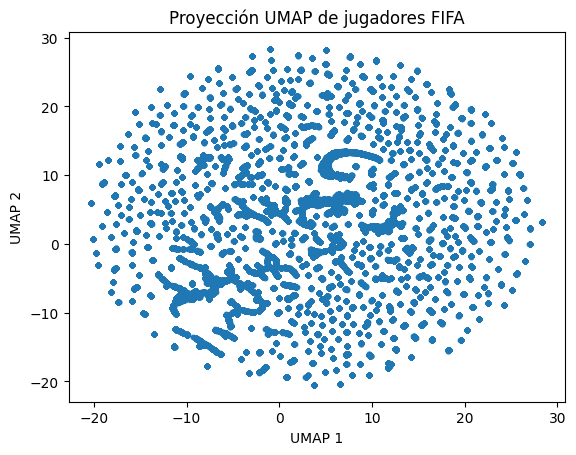

In [31]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(embedding[:,0], embedding[:,1], s=10)
plt.title("Proyección UMAP de jugadores FIFA")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

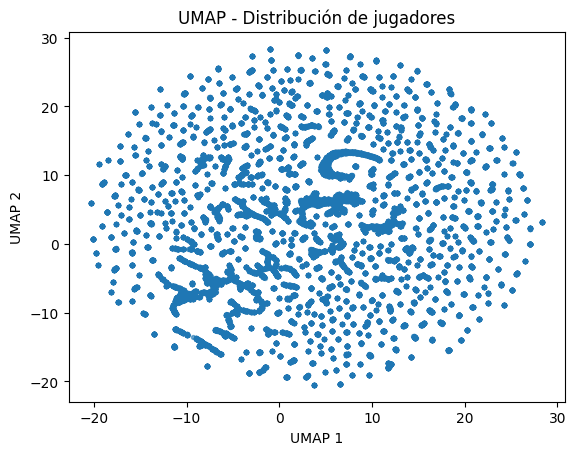

In [32]:
plt.figure()
plt.scatter(embedding[:,0], embedding[:,1], s=8, alpha=0.6)
plt.title("UMAP - Distribución de jugadores")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

Visualizar clusters (muy útil)

Como estás haciendo análisis de datos, puedes aplicar clustering después.

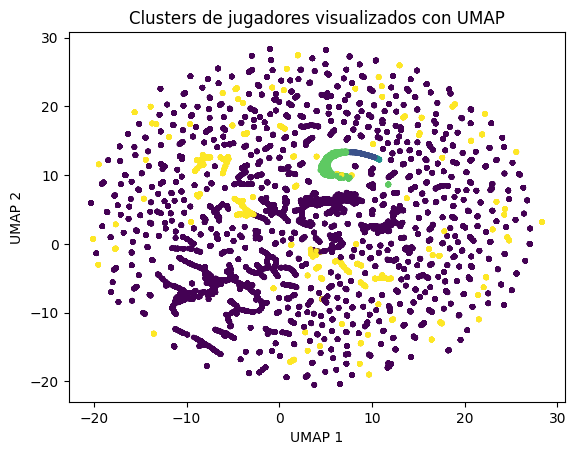

In [33]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X)

plt.figure()
plt.scatter(embedding[:,0], embedding[:,1], c=clusters, s=8)
plt.title("Clusters de jugadores visualizados con UMAP")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

## 6. Interpretación

- Los puntos cercanos representan datos similares.
- UMAP preserva la estructura local del dataset.
- Es útil para visualización y exploración antes de aplicar clustering.
